In [2]:
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import Counter
from dotenv import load_dotenv
from openai import OpenAI

In [3]:
# Auto labeling PURE dataset
LABELING_MODEL = "gpt-4o-mini"

# Agent model for clarification
AGENT_MODEL = "gpt-5.1"

In [2]:
# Load PROMISE dataset
# Common column names are: 'RequirementText', 'class', or 'label'
def load_arff_as_df(filepath):
    data_rows = []
    attributes = []
    reading_data = False

    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('%'):
                continue
            if line.lower().startswith('@attribute'):
                parts = line.split(None, 2)
                attributes.append(parts[1])
            elif line.lower().startswith('@data'):
                reading_data = True
            elif reading_data:
                row = []
                current = ''
                in_quotes = False
                for char in line:
                    if char == "'" and not in_quotes:
                        in_quotes = True
                    elif char == "'" and in_quotes:
                        in_quotes = False
                    elif char == ',' and not in_quotes:
                        row.append(current.strip().strip("'"))
                        current = ''
                    else:
                        current += char
                row.append(current.strip().strip("'"))
                if len(row) == len(attributes):
                    data_rows.append(row)

    return pd.DataFrame(data_rows, columns=attributes)


promise_df = load_arff_as_df('../data/raw/PROMISE/se-requirements-classification-master/0-datasets/PROMISE_exp/PROMISE_exp.arff')

print("Shape:", promise_df.shape)
print("\nColumns:", promise_df.columns.tolist())
print("\nLabel distribution:")
print(promise_df.iloc[:, -1].value_counts())
promise_df.head()

Shape: (969, 3)

Columns: ['ProjectID', 'RequirementText', '_class_']

Label distribution:
_class_
F     444
SE    125
US     85
O      77
PE     67
LF     49
A      31
MN     24
SC     22
FT     18
L      15
PO     12
Name: count, dtype: int64


,ProjectID,RequirementText,_class_
0,1,The system shall refresh the display every 60 ...,PE
1,1,The application shall match the color of the s...,LF
2,1,If projected the data must be readable. On a...,US
3,1,The product shall be available during normal b...,A
4,1,If projected the data must be understandable....,US


Using label column: _class_

Label distribution in PROMISE:
_class_
F     444
SE    125
US     85
O      77
PE     67
LF     49
A      31
MN     24
SC     22
FT     18
L      15
PO     12
Name: count, dtype: int64


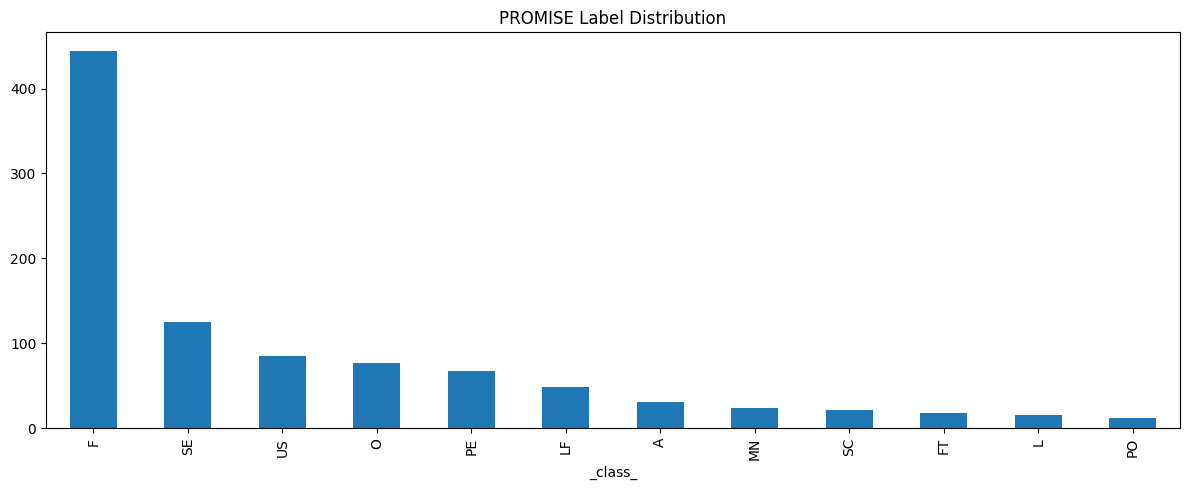

In [4]:
label_col = promise_df.columns[-1]
print("Using label column:", label_col)

print("\nLabel distribution in PROMISE:")
print(promise_df[label_col].value_counts())

# Visualize
promise_df[label_col].value_counts().plot(kind='bar', figsize=(12,5), title='PROMISE Label Distribution')
plt.tight_layout()
plt.show()

In [8]:
import xml.etree.ElementTree as ET
import re
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
print("API key loaded:", api_key[:8] + "..." if api_key else "NOT FOUND - check .env file")

client = OpenAI(api_key=api_key)

def clean_text_block(text):
    """Clean a raw XML text block before sentence splitting."""
    if not text:
        return ""
    text = re.sub(r'\s+', ' ', text)          # collapse all whitespace/newlines
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) # remove non-ASCII characters
    return text.strip()

def strip_leading_id(sentence):
    """
    Strip leading requirement IDs or list markers before validation.
    Handles formats like: [SSS004], [REQ-01], 1., (a), (I), 1.2.3
    Returns the cleaned sentence, or the original if nothing was stripped.
    """
    cleaned = re.sub(
        r'^(\[[\w\-]+\]|\([\w]+\)|\d+(\.\d+)*\.?)\s*',
        '', sentence
    ).strip()
    # Only return the stripped version if something meaningful remains
    return cleaned if len(cleaned) > 0 else sentence

def is_valid_sentence(sentence):
    """
    Filter out structurally bad sentences.
    Verb checking is intentionally removed — let the LLM decide
    what is and isn't a requirement during labeling.
    """
    sentence = sentence.strip()

    # Too short to be a meaningful requirement
    if len(sentence) < 30:
        return False

    # Strip leading IDs/list numbers, then check if it starts with lowercase
    stripped = strip_leading_id(sentence)
    if stripped and stripped[0].islower():
        return False

    # Ends with colon — broken list header (e.g. "The system shall support:")
    if sentence.endswith(':'):
        return False

    return True

def extract_sentences_from_xml(filepath):
    sentences = []
    try:
        tree = ET.parse(filepath)
        root = tree.getroot()

        # Strip XML namespace from all tags
        for elem in root.iter():
            elem.tag = re.sub(r'\{.*?\}', '', elem.tag)

        for elem in root.iter('text_body'):
            if elem.text:
                cleaned = clean_text_block(elem.text)
                if not cleaned:
                    continue

                # Use NLTK for smart sentence splitting (handles abbreviations)
                split_sentences = sent_tokenize(cleaned)

                for sent in split_sentences:
                    sent = sent.strip()
                    if is_valid_sentence(sent):
                        sentences.append(sent)

    except Exception as e:
        print(f"Error parsing {filepath}: {e}")

    return sentences

# Testing before running on the full dataset
# test_file = '../data/raw/PURE/1414117/requirements-xml/XMLZIPFile/2003 - qheadache.xml'
# test_sentences = extract_sentences_from_xml(test_file)
# print(f"Found {len(test_sentences)} valid sentences")
# print("\nSample:")
# for s in test_sentences[:5]:
#     print(f"  - {s}")

def auto_label_requirement(sentence):
    """
    Label a single requirement sentence using GPT.
    Uses explicit prompt instructions to enforce raw label output only.
    Falls back to NFR_Other if an unexpected label is returned.
    """

    valid_labels = [
        'FR', 'NFR_Performance', 'NFR_Security', 'NFR_Usability',
        'NFR_Reliability', 'NFR_Maintainability', 'NFR_Scalability',
        'NFR_Portability', 'NFR_Operational', 'NFR_Legal',
        'NFR_LookAndFeel', 'NFR_Other', 'NOT_REQUIREMENT'
    ]

    # Format valid labels clearly for the prompt
    labels_str = ', '.join(valid_labels)

    prompt = f"""You are a requirements engineering expert.

Classify the sentence below into EXACTLY ONE label from this list:
{labels_str}

Label definitions:
- FR: describes what the system shall do (features, functions, behaviors)
- NFR_Performance: speed, response time, throughput, latency
- NFR_Security: authentication, encryption, access control, privacy
- NFR_Usability: ease of use, learnability, accessibility, user interface
- NFR_Reliability: availability, fault tolerance, recovery, uptime
- NFR_Maintainability: modularity, testability, extensibility, code quality
- NFR_Scalability: capacity, load handling, growth, concurrency
- NFR_Portability: platform compatibility, browser support, OS independence
- NFR_Operational: deployment, infrastructure, environment, monitoring
- NFR_Legal: compliance, regulations, licensing, standards
- NFR_LookAndFeel: visual design, branding, color schemes, layout style
- NFR_Other: non-functional requirement that does not fit any above category
- NOT_REQUIREMENT: introductory text, definitions, headings, background descriptions

OUTPUT RULES — you must follow these exactly:
1. Reply with ONLY the label string (e.g. FR or NFR_Security)
2. Do NOT include markdown formatting, backticks, or code blocks
3. Do NOT add any explanation, punctuation, or extra words
4. Do NOT invent labels outside the list above

Sentence: "{sentence}"
"""

    try:
        response = client.chat.completions.create(
            model=LABELING_MODEL,
            messages=[
                {
                    "role": "system",
                    "content": "You are a classification engine. You output only a single label string and nothing else."
                },
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            max_tokens=20,
            temperature=0
        )

        label = response.choices[0].message.content.strip()

        # Strip any accidental markdown backticks
        label = label.replace('`', '').strip()

        # Validate — reject anything outside the known label set
        if label not in valid_labels:
            print(f"Unexpected label '{label}' for: {sentence[:60]}... → defaulting to NFR_Other")
            return 'NFR_Other'

        return label

    except Exception as e:
        print(f"API error: {e} — retrying in 3s...")
        time.sleep(3)
        return 'NFR_Other'

API key loaded: sk-proj-...


In [9]:
import os
import glob
import time

xml_folder = '../data/raw/PURE/1414117/requirements-xml/XMLZIPFile/'
all_rows = []

xml_files = glob.glob(os.path.join(xml_folder, '*.xml'))
print(f"Found {len(xml_files)} XML files\n")

for xml_file in xml_files:
    doc_name = os.path.basename(xml_file)
    sentences = extract_sentences_from_xml(xml_file)
    
    print(f"Processing: {doc_name} ({len(sentences)} sentences)...")
    
    for sentence in sentences:
        label = auto_label_requirement(sentence)
        all_rows.append({
            'text': sentence,
            'label': label,
            'source': 'PURE',
            'document': doc_name
        })
        time.sleep(0.1)  # avoid rate limiting
    
    print(f"Done: {doc_name}")

# --- Build dataframe ---
pure_labeled_df = pd.DataFrame(all_rows)
print(f"\nTotal rows before cleaning: {len(pure_labeled_df)}")
print(f"\nRaw label distribution:\n{pure_labeled_df['label'].value_counts()}")

# --- Apply Cell 3 cleaning inline ---
# Fix whitespace
pure_labeled_df['text'] = pure_labeled_df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Remove fragments
pure_labeled_df = pure_labeled_df[pure_labeled_df['text'].str.match(r'^[\[\("\'\d]*[A-Z]')]

# Remove too short
pure_labeled_df = pure_labeled_df[pure_labeled_df['text'].str.len() >= 30]

# Remove duplicates
pure_labeled_df = pure_labeled_df.drop_duplicates(subset=['text'])

# Remove NOT_REQUIREMENT
not_req_count = (pure_labeled_df['label'] == 'NOT_REQUIREMENT').sum()
print(f"\nRemoving {not_req_count} NOT_REQUIREMENT rows...")
pure_labeled_df = pure_labeled_df[pure_labeled_df['label'] != 'NOT_REQUIREMENT']

# Keep only valid labels
valid_labels = [
    'FR', 'NFR_Performance', 'NFR_Security', 'NFR_Usability',
    'NFR_Reliability', 'NFR_Maintainability', 'NFR_Scalability',
    'NFR_Portability', 'NFR_Operational', 'NFR_Legal',
    'NFR_LookAndFeel', 'NFR_Other'
]
pure_labeled_df = pure_labeled_df[pure_labeled_df['label'].isin(valid_labels)]

# --- Final report ---
print(f"\nFinal rows after cleaning: {len(pure_labeled_df)}")
print(f"\nFinal label distribution:\n{pure_labeled_df['label'].value_counts()}")

# --- Save ---
pure_labeled_df.to_csv('../data/processed/pure_autolabeled.csv', index=False)
print("\nSaved pure_autolabeled.csv")

Found 18 XML files

Processing: 0000 - cctns.xml (197 sentences)...
Done: 0000 - cctns.xml
Processing: 0000 - gamma j.xml (180 sentences)...
Done: 0000 - gamma j.xml
Processing: 1995 - gemini.xml (547 sentences)...
Done: 1995 - gemini.xml
Processing: 1998 - themas.xml (177 sentences)...
Done: 1998 - themas.xml
Processing: 1999 - dii.xml (51 sentences)...
Done: 1999 - dii.xml
Processing: 1999 - tcs.xml (617 sentences)...
Done: 1999 - tcs.xml
Processing: 2003 - qheadache.xml (103 sentences)...
Done: 2003 - qheadache.xml
Processing: 2005 - microcare.xml (135 sentences)...
Done: 2005 - microcare.xml
Processing: 2005 - phin.xml (184 sentences)...
Done: 2005 - phin.xml
Processing: 2006 - eirene sys 15.xml (578 sentences)...
Done: 2006 - eirene sys 15.xml
Processing: 2007 - get real 0.2.xml (102 sentences)...
Done: 2007 - get real 0.2.xml
Processing: 2007-eirene_fun_7-2.xml (687 sentences)...
Done: 2007-eirene_fun_7-2.xml
Processing: 2007-ertms.xml (204 sentences)...
Done: 2007-ertms.xml
Proc

In [12]:
# --- Run auto-labeling on all PURE XML files ---
import os
import glob

xml_folder = '../data/raw/PURE/1414117/requirements-xml/XMLZIPFile/'
all_rows = []

xml_files = glob.glob(os.path.join(xml_folder, '*.xml'))
print(f"Found {len(xml_files)} XML files")

for xml_file in xml_files:
    doc_name = os.path.basename(xml_file)
    sentences = extract_sentences_from_xml(xml_file)
    
    for sentence in sentences:
        label = auto_label_requirement(sentence)
        all_rows.append({
            'text': sentence,
            'label': label,
            'source': 'PURE',
            'document': doc_name
        })
        time.sleep(0.1)  # avoid rate limiting
    
    print(f"Processed: {doc_name} ({len(sentences)} sentences)")

pure_labeled_df = pd.DataFrame(all_rows)

# Remove non-requirements
pure_labeled_df = pure_labeled_df[pure_labeled_df['label'] != 'NOT_REQUIREMENT']

print(f"\nTotal labeled sentences: {len(pure_labeled_df)}")
print(pure_labeled_df['label'].value_counts())

# Save
pure_labeled_df.to_csv('../data/processed/pure_autolabeled.csv', index=False)
print("Saved pure_autolabeled.csv")

Found 18 XML files
Processed: 0000 - cctns.xml (213 sentences)
Processed: 0000 - gamma j.xml (184 sentences)
Processed: 1995 - gemini.xml (614 sentences)
Processed: 1998 - themas.xml (190 sentences)
Processed: 1999 - dii.xml (59 sentences)
Processed: 1999 - tcs.xml (635 sentences)
Processed: 2003 - qheadache.xml (120 sentences)
Processed: 2005 - microcare.xml (143 sentences)
Processed: 2005 - phin.xml (189 sentences)
Processed: 2006 - eirene sys 15.xml (588 sentences)
Processed: 2007 - get real 0.2.xml (108 sentences)
Processed: 2007-eirene_fun_7-2.xml (765 sentences)
Processed: 2007-ertms.xml (220 sentences)
Processed: 2008 - keepass.xml (208 sentences)
Processed: 2008 - peering.xml (140 sentences)
Processed: 2009 - peppol approved.xml (1015 sentences)
Processed: 2009 - video search.xml (84 sentences)
Processed: 2010-blitdraft.xml (68 sentences)

Total labeled sentences: 4234
label
FR                     2965
NFR_Legal               290
NFR_Usability           167
NFR_Security        

In [ ]:
# PURE dataset — may come as multiple files or one CSV
pure_df = pd.read_csv('../data/processed/pure_autolabeled.csv')

print("Shape:", pure_df.shape)
print("\nColumns:", pure_df.columns.tolist())
pure_df.head()

In [ ]:
fr_nfr_df = pd.read_csv('../data/raw/fr_nfr_dataset.csv')  # adjust filename

print("Shape:", fr_nfr_df.shape)
print("\nColumns:", fr_nfr_df.columns.tolist())
fr_nfr_df.head()

In [ ]:
# ---- Standardize PROMISE ----
# Typical PROMISE columns: 'RequirementText', 'class'
promise_clean = pd.DataFrame({
    'text': promise_df['RequirementText'],  # change if your column name differs
    'label': promise_df['class'],           # change if your column name differs
    'source': 'PROMISE'
})

# ---- Standardize PURE ----
# Typical PURE columns may vary — inspect yours and adjust
pure_clean = pd.DataFrame({
    'text': pure_df['Text'],          # adjust
    'label': pure_df['Label'],        # adjust  
    'source': 'PURE'
})

# ---- Standardize FR_NFR ----
fr_nfr_clean = pd.DataFrame({
    'text': fr_nfr_df['RequirementText'],   # adjust
    'label': fr_nfr_df['RequirementType'],  # adjust
    'source': 'FR_NFR'
})

print("PROMISE labels:", promise_clean['label'].unique())
print("PURE labels:", pure_clean['label'].unique())
print("FR_NFR labels:", fr_nfr_clean['label'].unique())

In [ ]:
# Define your master label mapping
# Look at the unique labels printed above and map them here
label_mapping = {
    # PROMISE labels (common ones)
    'F'  : 'FR',
    'FR' : 'FR',
    'A'  : 'NFR_Availability',
    'FT' : 'NFR_FaultTolerance',
    'L'  : 'NFR_Legal',
    'LF' : 'NFR_LookAndFeel',
    'MN' : 'NFR_Maintainability',
    'O'  : 'NFR_Operational',
    'PE' : 'NFR_Performance',
    'PO' : 'NFR_Portability',
    'SC' : 'NFR_Scalability',
    'SE' : 'NFR_Security',
    'US' : 'NFR_Usability',
    
    # PURE / FR_NFR labels (common ones)
    'Functional'    : 'FR',
    'NonFunctional' : 'NFR_Other',
    'NFR'           : 'NFR_Other',
    '0'             : 'FR',
    '1'             : 'NFR_Other',
}

# Apply mapping to each dataset
promise_clean['label'] = promise_clean['label'].map(label_mapping)
pure_clean['label']    = pure_clean['label'].map(label_mapping)
fr_nfr_clean['label'] = fr_nfr_clean['label'].map(label_mapping)

# Drop any rows where label couldn't be mapped (NaN)
promise_clean.dropna(subset=['label'], inplace=True)
pure_clean.dropna(subset=['label'], inplace=True)
fr_nfr_clean.dropna(subset=['label'], inplace=True)

In [ ]:
# Merge all into one master dataframe
master_df = pd.concat([promise_clean, pure_clean, fr_nfr_clean], ignore_index=True)

print("Total records:", len(master_df))
print("\nLabel distribution:")
print(master_df['label'].value_counts())

master_df.sample(10)  # inspect random samples

In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)         # remove extra whitespace
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # remove non-ASCII characters
    return text

master_df['text'] = master_df['text'].apply(clean_text)

# Remove empty rows
master_df = master_df[master_df['text'].str.len() > 10]

print("After cleaning:", len(master_df), "records")

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
master_df['label_id'] = le.fit_transform(master_df['label'])

# Save the label mapping so you can decode predictions later
label2id = {label: idx for idx, label in enumerate(le.classes_)}
id2label = {idx: label for label, idx in label2id.items()}

print("Label encoding map:")
for k, v in label2id.items():
    print(f"  {k} → {v}")

In [ ]:
master_df.to_csv('../data/processed/master_dataset.csv', index=False)

# Also save label maps
import json
with open('../data/processed/label2id.json', 'w') as f:
    json.dump(label2id, f, indent=2)
with open('../data/processed/id2label.json', 'w') as f:
    json.dump(id2label, f, indent=2)

print("✅ Saved master_dataset.csv and label maps!")
print(f"Total samples: {len(master_df)}")
print(f"Number of classes: {len(label2id)}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Label distribution
master_df['label'].value_counts().plot(kind='bar', ax=axes[0], title='Final Label Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

# Source distribution
master_df['source'].value_counts().plot(kind='pie', ax=axes[1], title='Data Source Distribution', autopct='%1.1f%%')

plt.tight_layout()
plt.savefig('../data/processed/dataset_overview.png')
plt.show()
print("✅ Preprocessing complete!")